## reproducing Fig. 4 of Kitade and Kataoka 2026

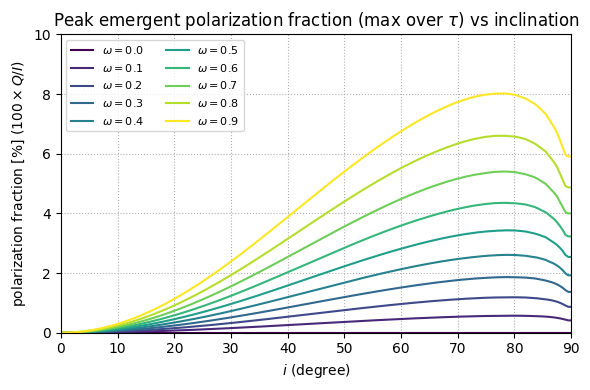

In [3]:
from emergentintensity import emergent_stokes, INTERP_TABLES

import numpy as np
import matplotlib.pyplot as plt

# ========== Assumptions ==========
# We assume that the following has already been executed:
#   TABLES, INTERP_TABLES = setup_tables(DATA_DIR)

tau_grid   = INTERP_TABLES["tau_grid"]              # shape (N_tau,)
omega_grid = np.array(INTERP_TABLES["omega_grid"])  # shape (N_omega,)
per_tau    = INTERP_TABLES["per_tau"]               # list of dicts, len = N_tau

# For Fig.4 we use the omega-grid from the tables directly
omega_arr = omega_grid.copy()

# Inclination i: 0–90 deg (0.5 deg steps)
inc_vals  = np.linspace(0.0, 90.0, 181)


# ========== Fast 1D linear interpolation along mu (NumPy version) ==========

def interp_mu_1d(mu, mu_grid, values):
    """
    1D linear interpolation in mu (for a fixed omega and tau).
    Values are clipped at the edges.
    """
    mu_val = float(mu)
    mu_grid = np.asarray(mu_grid, dtype=float)
    values  = np.asarray(values, dtype=float)

    mu_min = float(mu_grid[0])
    mu_max = float(mu_grid[-1])

    if mu_val <= mu_min:
        return float(values[0])
    if mu_val >= mu_max:
        return float(values[-1])

    idx_hi = int(np.searchsorted(mu_grid, mu_val, side="right"))
    idx_lo = idx_hi - 1

    x0 = float(mu_grid[idx_lo])
    x1 = float(mu_grid[idx_hi])
    t  = (mu_val - x0) / (x1 - x0)

    v0 = float(values[idx_lo])
    v1 = float(values[idx_hi])
    return float((1.0 - t) * v0 + t * v1)


# ========== For each omega and inclination, compute peak (Q/I) over tau ==========

PF_peak_map = {}   # omega -> peak(Q/I)(i) [%]

# Precompute indices of each omega in the omega_grid (they should match almost exactly)
omega_indices = []
for omega in omega_arr:
    idx = int(np.argmin(np.abs(omega_grid - omega)))
    omega_indices.append(idx)
omega_indices = np.array(omega_indices, dtype=int)

for omega, iw_grid in zip(omega_arr, omega_indices):
    PF_peak_list = []

    for inc in inc_vals:
        mu = float(np.cos(np.deg2rad(inc)))

        # For each tau, compute PF(tau, omega, mu) = Q/I from the tables
        pf_vs_tau = []
        for kt, tau in enumerate(tau_grid):
            rec = per_tau[kt]
            mu_grid_k = np.asarray(rec["mu_grid"], dtype=float)

            I_omega_mu = np.asarray(rec["I"][iw_grid, :], dtype=float)  # (N_mu,)
            Q_omega_mu = np.asarray(rec["Q"][iw_grid, :], dtype=float)  # (N_mu,)

            I_val = interp_mu_1d(mu, mu_grid_k, I_omega_mu)
            Q_val = interp_mu_1d(mu, mu_grid_k, Q_omega_mu)

            pf_val = 0.0 if I_val == 0.0 else (Q_val / I_val)
            pf_vs_tau.append(pf_val)

        pf_vs_tau = np.array(pf_vs_tau, dtype=float)
        pf_peak   = float(np.max(pf_vs_tau))        # peak PF at this (omega, i)
        PF_peak_list.append(100.0 * pf_peak)        # convert to [%]

    PF_peak_map[omega] = np.array(PF_peak_list, dtype=float)


# ========== Plot (Fig.4 reproduction) ==========

plt.figure(figsize=(6, 4))

colors = plt.cm.viridis(np.linspace(0.0, 1.0, len(omega_arr)))

for omega, c in zip(omega_arr, colors):
    plt.plot(inc_vals, PF_peak_map[omega], color=c, label=fr"$\omega={omega:.1f}$")

plt.xlabel(r"$i$ (degree)")
plt.ylabel(r"polarization fraction [%] ($100\times Q/I$)")
plt.xlim(0.0, 90.0)
plt.ylim(0.0, 10.0)     # adjust if needed
plt.grid(True, ls=":")
plt.legend(ncol=2, fontsize=8, loc="best")
plt.title(r"Peak emergent polarization fraction (max over $\tau$) vs inclination")

plt.tight_layout()